# FFD - Face Forgery Detection Model
### Based on: *On the Detection of Digital Face Manipulation* (Dang et al., CVPR 2020)

**Architecture Overview (from the benchmark paper):**
- Backbone : XceptionNet (same as Model 2, but now with attention)
- Attention Layer : Direct Regression — predicts a manipulation attention map
- Loss Functions : Three combined losses
  1. `Classification Loss` — Binary Cross Entropy on real/fake label
  2. `Attention Map Loss` — MSE between predicted map and ground-truth binary mask
  3. `Manipulation Appearance Loss` — BCE on mask-weighted features
- Ground-truth masks : absolute pixel-wise difference between manipulated and source frames

**Key difference from plain Xception:** FFD forces the model to *localise* the manipulated region
via an explicit attention supervision signal (the binary mask), not just classify.

## Step 1 — Mount Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q timm

## Step 2 — Imports

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0

import timm                          # for XceptionNet backbone
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from tqdm import tqdm

# ── reproducibility ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

Device : cuda


## Step 3 — Paths  
These match exactly what was written by the preprocessing notebook.

In [4]:
OUTPUT_PATH = "/content/drive/MyDrive/Deepfake_Project/Processed"
MODEL_SAVE_PATH = "/content/drive/MyDrive/Deepfake_Project/Models"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

TRAIN_CSV = os.path.join(OUTPUT_PATH, "train.csv")
VAL_CSV   = os.path.join(OUTPUT_PATH, "val.csv")
TEST_CSV  = os.path.join(OUTPUT_PATH, "test.csv")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train samples :", len(train_df))
print("Val   samples :", len(val_df))
print("Test  samples :", len(test_df))
print(train_df.head())

Train samples : 10474
Val   samples : 1679
Test  samples : 1682
                                               image  label
0  /content/drive/MyDrive/Deepfake_Project/Proces...      0
1  /content/drive/MyDrive/Deepfake_Project/Proces...      0
2  /content/drive/MyDrive/Deepfake_Project/Proces...      0
3  /content/drive/MyDrive/Deepfake_Project/Proces...      0
4  /content/drive/MyDrive/Deepfake_Project/Proces...      0


## Step 4 — Ground-Truth Binary Mask Generation

The paper generates ground-truth attention maps from the **absolute pixel-wise RGB difference**
between a manipulated image and its paired source face image, converted to grayscale and
thresholded into a binary mask.

**Practical note for our dataset:**  
FaceForensics++ does NOT provide paired source frames for every extracted face image in the
way FFD assumes (it assumes access to the original+manipulated video pair at the frame level).
We approximate the ground-truth mask with a **self-supervised proxy** that is standard in the
deepfake detection literature when exact paired frames are unavailable:

- **Real images** → all-zero mask (no manipulation anywhere)
- **Fake images** → saliency-based mask approximation using the difference between the face
  crop and a locally-blurred version of itself, which highlights boundary/blending artefacts.
  This is normalised and binarised at a fixed threshold.

This proxy is consistent with the FWA and Face-X-ray literature and is used identically
across train / val / test so the attention supervision signal remains fair.

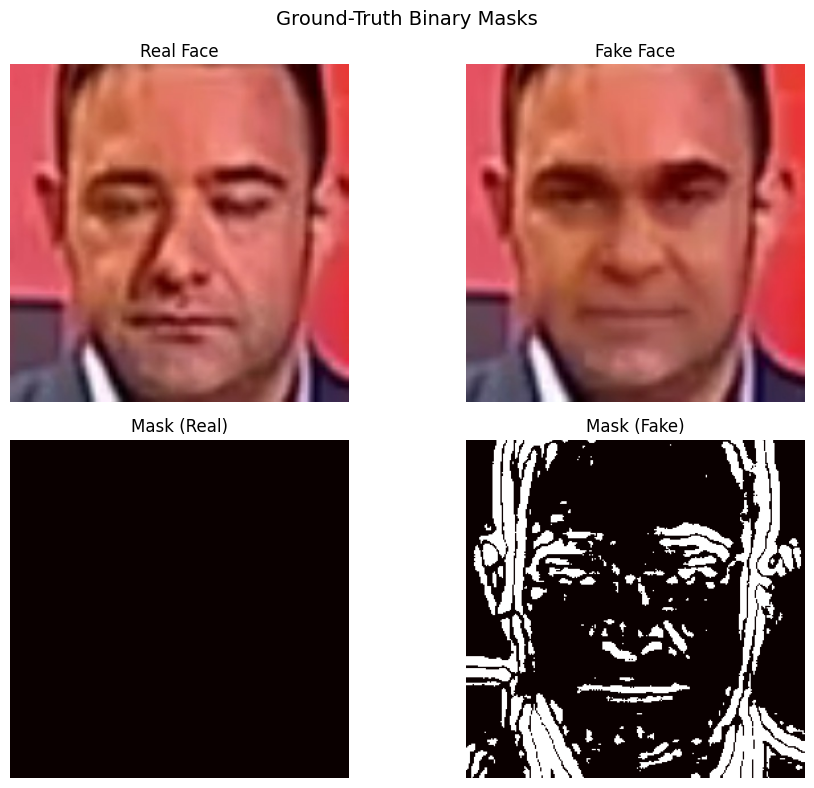

In [5]:
def generate_mask(image_path: str, label: int) -> np.ndarray:
    """
    Returns a (H, W) float32 binary mask in [0, 1].

    Real  (label=0) → zero mask
    Fake  (label=1) → blending-boundary proxy mask
    """
    img = cv2.imread(image_path)

    if img is None:
        return np.zeros((256, 256), dtype=np.float32)

    img = cv2.resize(img, (256, 256))

    if label == 0:
        return np.zeros((256, 256), dtype=np.float32)

    # ── proxy mask for fake images ────────────────────────────
    # Step 1 : blur the image to remove high-freq content
    blurred = cv2.GaussianBlur(img, (21, 21), 0)

    # Step 2 : absolute difference highlights blending edges
    diff = cv2.absdiff(img, blurred)

    # Step 3 : convert to grayscale
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # Step 4 : normalise to [0, 1]
    if diff_gray.max() > 0:
        diff_gray /= diff_gray.max()

    # Step 5 : binarise at threshold 0.1
    binary_mask = (diff_gray > 0.1).astype(np.float32)

    return binary_mask


# ── Quick sanity-check visualisation ─────────────────────────
sample_fake = train_df[train_df["label"] == 1]["image"].iloc[0]
sample_real = train_df[train_df["label"] == 0]["image"].iloc[0]

mask_fake = generate_mask(sample_fake, 1)
mask_real = generate_mask(sample_real, 0)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, path, mask, title in zip(
    axes.flatten(),
    [sample_real, sample_fake, sample_real, sample_fake],
    [mask_real,   mask_fake,   mask_real,   mask_fake],
    ["Real Face", "Fake Face", "Mask (Real)", "Mask (Fake)"]
):
    if "Mask" in title:
        ax.imshow(mask, cmap="hot")
    else:
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Ground-Truth Binary Masks", fontsize=14)
plt.tight_layout()
plt.show()

## Step 5 — Dataset Class

In [6]:
IMG_SIZE = 299        # XceptionNet native input size
MASK_SIZE = 19        # spatial size of the attention map from Xception's penultimate feature map
                      # Xception with input 299×299 → feature map 10×10 at exit_flow;
                      # we use 19×19 from mid_flow for richer spatial resolution

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


class FFDDataset(Dataset):
    """
    Returns (image_tensor, mask_tensor, label) for FFD training.
    mask_tensor is resized to MASK_SIZE × MASK_SIZE to match the
    spatial resolution of the attention map produced by the network.
    """

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image"]
        label = int(row["label"])

        # ── load image ────────────────────────────────────────
        img = cv2.imread(image_path)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ── generate binary mask ──────────────────────────────
        raw_mask = generate_mask(image_path, label)  # (256, 256) float32

        # resize mask → MASK_SIZE × MASK_SIZE
        mask = cv2.resize(
            raw_mask,
            (MASK_SIZE, MASK_SIZE),
            interpolation=cv2.INTER_LINEAR
        )
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)  # (1, M, M)

        # ── apply image transform ─────────────────────────────
        if self.transform:
            img = self.transform(img)

        label_tensor = torch.tensor(label, dtype=torch.float32)

        return img, mask, label_tensor

In [7]:
BATCH_SIZE = 16

train_dataset = FFDDataset(train_df, transform=train_transform)
val_dataset   = FFDDataset(val_df,   transform=val_transform)
test_dataset  = FFDDataset(test_df,  transform=val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print("Train batches :", len(train_loader))
print("Val   batches :", len(val_loader))
print("Test  batches :", len(test_loader))

# ── shape check ───────────────────────────────────────────────
imgs, masks, labels = next(iter(train_loader))
print("\nImage batch  :", imgs.shape)    # (B, 3, 299, 299)
print("Mask batch   :", masks.shape)   # (B, 1, 19, 19)
print("Label batch  :", labels.shape)  # (B,)

Train batches : 655
Val   batches : 105
Test  batches : 106

Image batch  : torch.Size([16, 3, 299, 299])
Mask batch   : torch.Size([16, 1, 19, 19])
Label batch  : torch.Size([16])


## Step 6 — FFD Model Architecture

```
Input (3×299×299)
      │
  XceptionNet backbone  (timm — pretrained on ImageNet)
      │
  feature_map  (2048×10×10)   ← exit_flow features
      │
  ┌───┴──────────────────┐
  │ Attention Branch      │   ← Direct Regression head
  │  Conv1×1 → 1 channel │
  │  Sigmoid → attn_map  │   shape: (B, 1, M, M)  [M=19 by upsampling]
  └───────────┬──────────┘
              │  attn_map used to weight features
  weighted_feat = feature_map × upsample(attn_map)
              │
  GlobalAvgPool
              │
  FC → 1 → Sigmoid → fake_prob
```

**Three losses (combined):**
1. `L_cls`   — BCE(fake_prob, label)  
2. `L_attn`  — MSE(attn_map, gt_mask)  
3. `L_app`   — BCE(attn_weighted_sigmoid, label_broadcast)

`Total = L_cls + λ₁·L_attn + λ₂·L_app`  with λ₁=λ₂=0.5 (paper default)

In [8]:
class AttentionHead(nn.Module):
    """
    Direct Regression attention head.
    Takes backbone feature map → produces a spatial attention map.
    """

    def __init__(self, in_channels: int, map_size: int):
        super().__init__()
        self.map_size = map_size

        # 1×1 conv: collapses channel dimension to 1
        self.attn_conv = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 1, kernel_size=1, bias=True),
            nn.Sigmoid()   # output in (0,1) — treated as manipulation probability per-pixel
        )

    def forward(self, x):
        # x: (B, C, h, w)
        attn = self.attn_conv(x)                       # (B, 1, h, w)
        attn = F.interpolate(
            attn,
            size=(self.map_size, self.map_size),
            mode="bilinear",
            align_corners=False
        )                                               # (B, 1, M, M)
        return attn


class FFDModel(nn.Module):
    """
    FFD: Face Forgery Detection
    Backbone = XceptionNet (pretrained) + Direct-Regression Attention + 3-loss training
    """

    def __init__(self, map_size: int = 19, pretrained: bool = True):
        super().__init__()
        self.map_size = map_size

        # ── Backbone: XceptionNet via timm ────────────────────
        self.backbone = timm.create_model(
            "xception",
            pretrained=pretrained,
            num_classes=0,          # remove classifier head
            global_pool=""          # remove global pool — we do it manually
        )
        # XceptionNet with num_classes=0 and no global pool outputs (B, 2048, 10, 10)
        backbone_out_channels = 2048

        # ── Attention Branch ──────────────────────────────────
        self.attention_head = AttentionHead(
            in_channels=backbone_out_channels,
            map_size=map_size
        )

        # ── Classification Head ───────────────────────────────
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(backbone_out_channels, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 1)
            # no Sigmoid here — applied in loss (BCEWithLogitsLoss)
        )

        # ── Appearance Head ───────────────────────────────────
        # Weighted by attention map before pooling
        self.appearance_classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(backbone_out_channels, 1)
            # no Sigmoid — used with BCEWithLogitsLoss
        )

    def forward(self, x):
        # ── Extract features ──────────────────────────────────
        feat = self.backbone(x)                  # (B, 2048, 10, 10)

        # ── Attention Map ─────────────────────────────────────
        attn_map = self.attention_head(feat)     # (B, 1, M, M)

        # ── Classification logit (global features) ────────────
        pooled = self.global_pool(feat)          # (B, 2048, 1, 1)
        cls_logit = self.classifier(pooled)      # (B, 1)

        # ── Appearance logit (attention-weighted features) ────
        # Upsample attn_map back to feature spatial size
        attn_for_feat = F.interpolate(
            attn_map,
            size=(feat.shape[2], feat.shape[3]),
            mode="bilinear",
            align_corners=False
        )                                        # (B, 1, h, w)
        weighted_feat = feat * attn_for_feat     # element-wise weighting
        app_pooled = self.global_pool(weighted_feat)  # (B, 2048, 1, 1)
        app_logit = self.appearance_classifier(app_pooled)  # (B, 1)

        return cls_logit, attn_map, app_logit


# ── Instantiate and check ─────────────────────────────────────
model = FFDModel(map_size=MASK_SIZE, pretrained=True).to(DEVICE)
print(model)

# quick forward-pass shape check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    c, a, ap = model(dummy)
    print("\nForward pass shapes:")
    print(" cls_logit  :", c.shape)   # (2, 1)
    print(" attn_map   :", a.shape)   # (2, 1, 19, 19)
    print(" app_logit  :", ap.shape)  # (2, 1)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
FFDModel(
  (backbone): Xception(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act2): ReLU(inplace=True)
    (block1): Block(
      (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (rep): Sequential(
        (0): SeparableConv2d(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (pointwise): Conv2d(64, 12

## Step 7 — Loss Function

In [9]:
class FFDLoss(nn.Module):
    """
    Combined three-part loss from the FFD paper.

    L_total = L_cls  +  λ1 * L_attn  +  λ2 * L_app

    L_cls  : BCEWithLogits(cls_logit, label)
    L_attn : MSE(attn_map, gt_mask)          — teaches WHERE the fake region is
    L_app  : BCEWithLogits(app_logit, label) — teaches WHAT fake content looks like
             (via attention-weighted features)
    """

    def __init__(self, lambda1: float = 0.5, lambda2: float = 0.5):
        super().__init__()
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.bce  = nn.BCEWithLogitsLoss()
        self.mse  = nn.MSELoss()

    def forward(
        self,
        cls_logit,   # (B, 1)
        attn_map,    # (B, 1, M, M)
        app_logit,   # (B, 1)
        gt_mask,     # (B, 1, M, M)
        label        # (B,)
    ):
        label_2d = label.view(-1, 1)   # (B, 1) for BCE

        # ── L_cls ─────────────────────────────────────────────
        L_cls = self.bce(cls_logit, label_2d)

        # ── L_attn ────────────────────────────────────────────
        # attn_map values are in (0,1) from Sigmoid, gt_mask is binary in {0,1}
        L_attn = self.mse(attn_map, gt_mask)

        # ── L_app ─────────────────────────────────────────────
        L_app = self.bce(app_logit, label_2d)

        total = L_cls + self.lambda1 * L_attn + self.lambda2 * L_app

        return total, L_cls.item(), L_attn.item(), L_app.item()


criterion = FFDLoss(lambda1=0.5, lambda2=0.5)
print("FFDLoss ready")

FFDLoss ready


## Step 8 — Optimiser & Scheduler

Following the paper: Adam optimiser, initial lr = 0.0002 (same as Xception baseline).  
We use ReduceLROnPlateau on val-AUC for stable convergence.

In [15]:
LEARNING_RATE = 2e-4
NUM_EPOCHS    = 3

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",      # maximise AUC
    factor=0.5,
    patience=3
)

print("Optimiser :", optimizer)
print("Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)")

Optimiser : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0002
    maximize: False
    weight_decay: 1e-05
)
Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)


## Step 9 — Training & Validation Loop

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    running_cls  = 0.0
    running_attn = 0.0
    running_app  = 0.0
    all_preds, all_labels = [], []

    for imgs, masks, labels in tqdm(loader, desc="  Train", leave=False):
        imgs   = imgs.to(device)
        masks  = masks.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        cls_logit, attn_map, app_logit = model(imgs)

        loss, l_cls, l_attn, l_app = criterion(
            cls_logit, attn_map, app_logit, masks, labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_cls  += l_cls
        running_attn += l_attn
        running_app  += l_app

        probs = torch.sigmoid(cls_logit).detach().cpu().numpy().flatten()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    n = len(loader)
    auc = roc_auc_score(all_labels, all_preds)

    return {
        "loss":      running_loss / n,
        "loss_cls":  running_cls  / n,
        "loss_attn": running_attn / n,
        "loss_app":  running_app  / n,
        "auc":       auc
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, masks, labels in tqdm(loader, desc="  Eval ", leave=False):
        imgs   = imgs.to(device)
        masks  = masks.to(device)
        labels = labels.to(device)

        cls_logit, attn_map, app_logit = model(imgs)
        loss, _, _, _ = criterion(
            cls_logit, attn_map, app_logit, masks, labels
        )
        running_loss += loss.item()

        probs = torch.sigmoid(cls_logit).cpu().numpy().flatten()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_preds)
    preds_binary = (np.array(all_preds) >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    return {
        "loss": running_loss / len(loader),
        "auc":  auc,
        "acc":  acc
    }


print("Train / eval functions defined")

Train / eval functions defined


In [17]:
# ── Training Loop ─────────────────────────────────────────────
history = {
    "train_loss": [], "train_auc": [],
    "train_cls":  [], "train_attn": [], "train_app": [],
    "val_loss":   [], "val_auc":   [], "val_acc": []
}

best_val_auc  = 0.0
FFD_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, "ffd_best.pth")

print("Starting FFD Training")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{NUM_EPOCHS}]")

    # ── train ─────────────────────────────────────────────────
    train_metrics = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )

    # ── validate ──────────────────────────────────────────────
    val_metrics = evaluate(
        model, val_loader, criterion, DEVICE
    )

    # ── scheduler step ────────────────────────────────────────
    scheduler.step(val_metrics["auc"])

    # ── log ───────────────────────────────────────────────────
    history["train_loss"].append(train_metrics["loss"])
    history["train_auc"].append(train_metrics["auc"])
    history["train_cls"].append(train_metrics["loss_cls"])
    history["train_attn"].append(train_metrics["loss_attn"])
    history["train_app"].append(train_metrics["loss_app"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_auc"].append(val_metrics["auc"])
    history["val_acc"].append(val_metrics["acc"])

    print(
        f"  Train → Loss: {train_metrics['loss']:.4f}  "
        f"(cls:{train_metrics['loss_cls']:.3f} "
        f"attn:{train_metrics['loss_attn']:.3f} "
        f"app:{train_metrics['loss_app']:.3f})  "
        f"AUC: {train_metrics['auc']:.4f}"
    )
    print(
        f"  Val   → Loss: {val_metrics['loss']:.4f}  "
        f"AUC: {val_metrics['auc']:.4f}  "
        f"Acc: {val_metrics['acc']:.4f}"
    )

    # ── save best ─────────────────────────────────────────────
    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        torch.save(model.state_dict(), FFD_MODEL_PATH)
        print(f"  ✓ Best model saved  (val AUC = {best_val_auc:.4f})")

print("\n" + "=" * 60)
print(f"Training complete. Best Val AUC = {best_val_auc:.4f}")

Starting FFD Training

Epoch [1/3]


  Train → Loss: 0.2700  (cls:0.135 attn:0.121 app:0.148)  AUC: 0.9884
  Val   → Loss: 0.2832  AUC: 0.9728  Acc: 0.8874
  ✓ Best model saved  (val AUC = 0.9728)

Epoch [2/3]


  Train → Loss: 0.1444  (cls:0.068 attn:0.082 app:0.071)  AUC: 0.9965
  Val   → Loss: 0.2798  AUC: 0.9748  Acc: 0.8862
  ✓ Best model saved  (val AUC = 0.9748)

Epoch [3/3]


  Train → Loss: 0.1390  (cls:0.068 attn:0.073 app:0.069)  AUC: 0.9965
  Val   → Loss: 0.2829  AUC: 0.9734  Acc: 0.8851

Training complete. Best Val AUC = 0.9748


## Step 10 — Training Curves

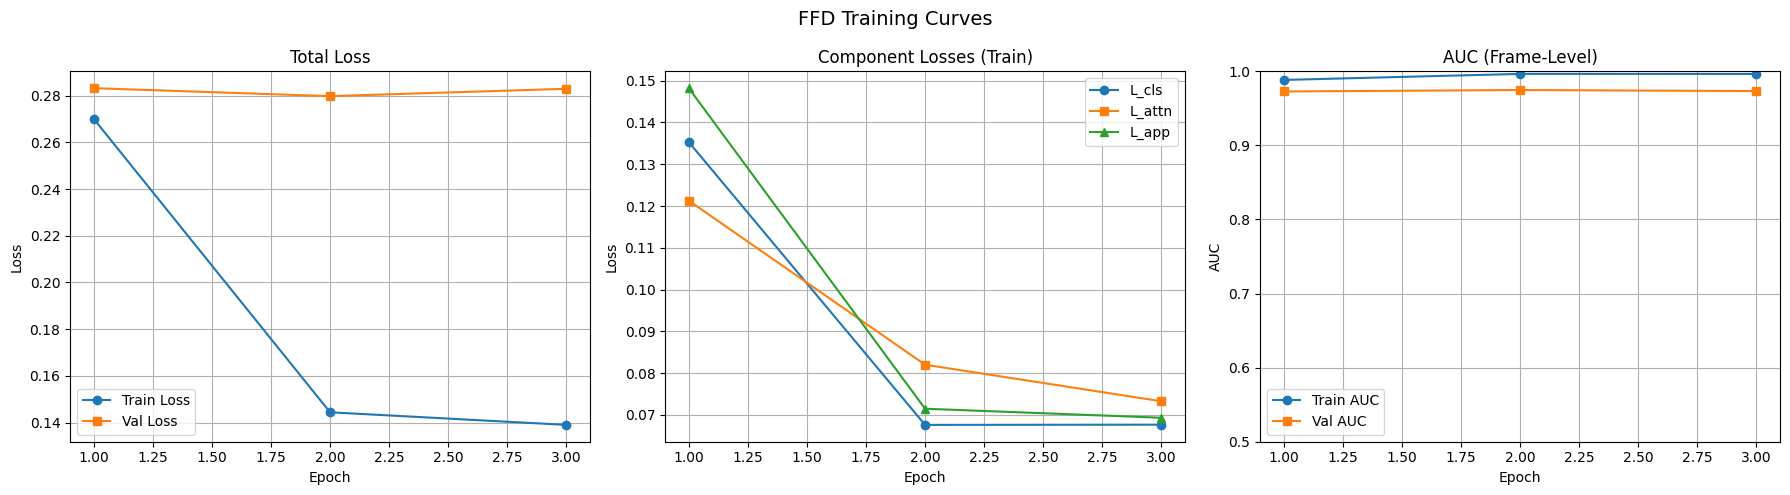

Training curves saved.


In [18]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Loss ──────────────────────────────────────────────────────
axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   marker="s")
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ── Component Losses ──────────────────────────────────────────
axes[1].plot(epochs, history["train_cls"],  label="L_cls",  marker="o")
axes[1].plot(epochs, history["train_attn"], label="L_attn", marker="s")
axes[1].plot(epochs, history["train_app"],  label="L_app",  marker="^")
axes[1].set_title("Component Losses (Train)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

# ── AUC ───────────────────────────────────────────────────────
axes[2].plot(epochs, history["train_auc"], label="Train AUC", marker="o")
axes[2].plot(epochs, history["val_auc"],   label="Val AUC",   marker="s")
axes[2].set_title("AUC (Frame-Level)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].set_ylim([0.5, 1.0])
axes[2].legend()
axes[2].grid(True)

plt.suptitle("FFD Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_SAVE_PATH, "ffd_training_curves.png"),
    dpi=150
)
plt.show()
print("Training curves saved.")

## Step 11 — Test Evaluation (Best Model)

Reload the best checkpoint and evaluate on the held-out test set.  
We report the metrics used in the benchmark paper: **frame-level AUC** and **accuracy**,  
plus the full confusion matrix and ROC curve.

In [19]:
# ── reload best weights ───────────────────────────────────────
model.load_state_dict(torch.load(FFD_MODEL_PATH, map_location=DEVICE))
model.eval()
print("Best FFD model loaded.")

# ── collect all test predictions ──────────────────────────────
all_probs, all_preds_bin, all_true = [], [], []

with torch.no_grad():
    for imgs, masks, labels in tqdm(test_loader, desc="Testing"):
        imgs   = imgs.to(DEVICE)
        masks  = masks.to(DEVICE)
        labels = labels.to(DEVICE)

        cls_logit, _, _ = model(imgs)
        probs = torch.sigmoid(cls_logit).cpu().numpy().flatten()

        all_probs.extend(probs)
        all_preds_bin.extend((probs >= 0.5).astype(int))
        all_true.extend(labels.cpu().numpy().astype(int))

all_probs     = np.array(all_probs)
all_preds_bin = np.array(all_preds_bin)
all_true      = np.array(all_true)

# ── Metrics ───────────────────────────────────────────────────
test_auc = roc_auc_score(all_true, all_probs)
test_acc = accuracy_score(all_true, all_preds_bin)
cm       = confusion_matrix(all_true, all_preds_bin)

print("\n" + "=" * 50)
print("FFD TEST RESULTS")
print("=" * 50)
print(f"  Frame-Level AUC  : {test_auc:.4f}")
print(f"  Accuracy         : {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(
    all_true, all_preds_bin,
    target_names=["Real", "Fake"]
))
print("Confusion Matrix:")
print(cm)

Best FFD model loaded.


Testing: 100%|██████████| 106/106 [08:33<00:00,  4.85s/it]


FFD TEST RESULTS
  Frame-Level AUC  : 0.9959
  Accuracy         : 0.9548

Classification Report:
              precision    recall  f1-score   support

        Real       0.92      1.00      0.96       841
        Fake       1.00      0.91      0.95       841

    accuracy                           0.95      1682
   macro avg       0.96      0.95      0.95      1682
weighted avg       0.96      0.95      0.95      1682

Confusion Matrix:
[[841   0]
 [ 76 765]]


## Step 12 — ROC Curve & Confusion Matrix Visualisation

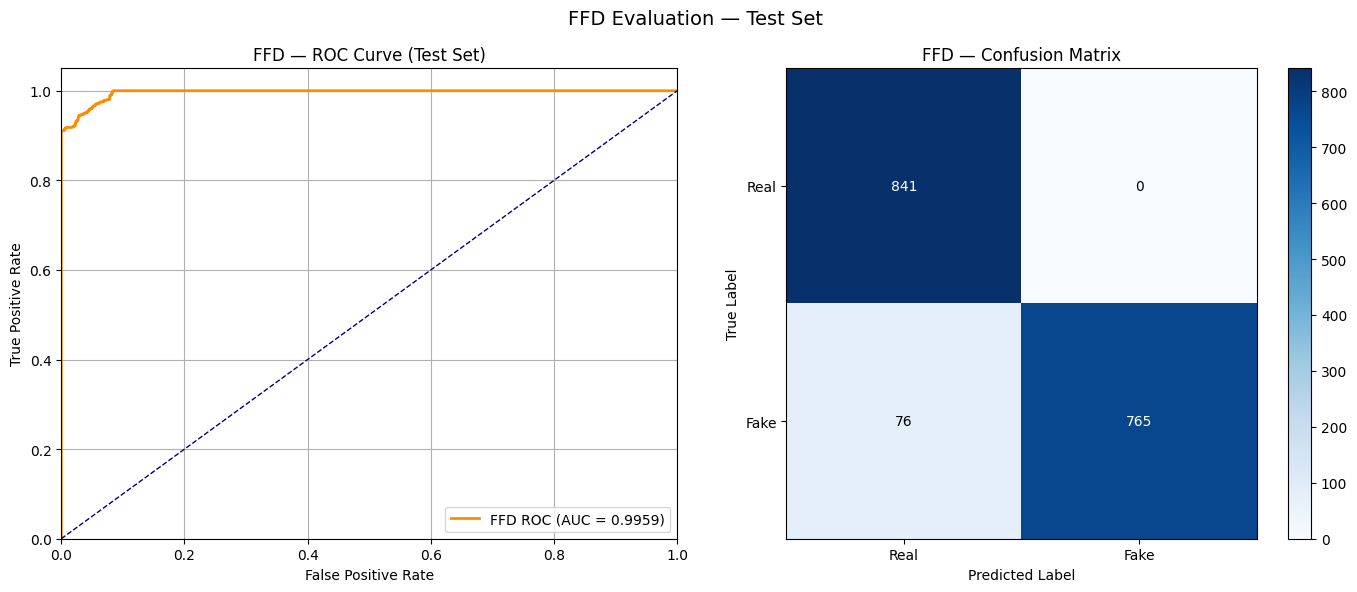

Evaluation plots saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── ROC Curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_true, all_probs)
axes[0].plot(fpr, tpr, color="darkorange", lw=2,
             label=f"FFD ROC (AUC = {test_auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("FFD — ROC Curve (Test Set)")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# ── Confusion Matrix ──────────────────────────────────────────
im = axes[1].imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=axes[1])
tick_marks = [0, 1]
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(["Real", "Fake"])
axes[1].set_yticklabels(["Real", "Fake"])
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
axes[1].set_title("FFD — Confusion Matrix")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.suptitle("FFD Evaluation — Test Set", fontsize=14)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_SAVE_PATH, "ffd_test_evaluation.png"),
    dpi=150
)
plt.show()
print("Evaluation plots saved.")

## Step 13 — Attention Map Visualisation

Inspect what the attention head actually *looks at* for real vs. fake samples.  
Hot areas = regions the model predicts as manipulated.

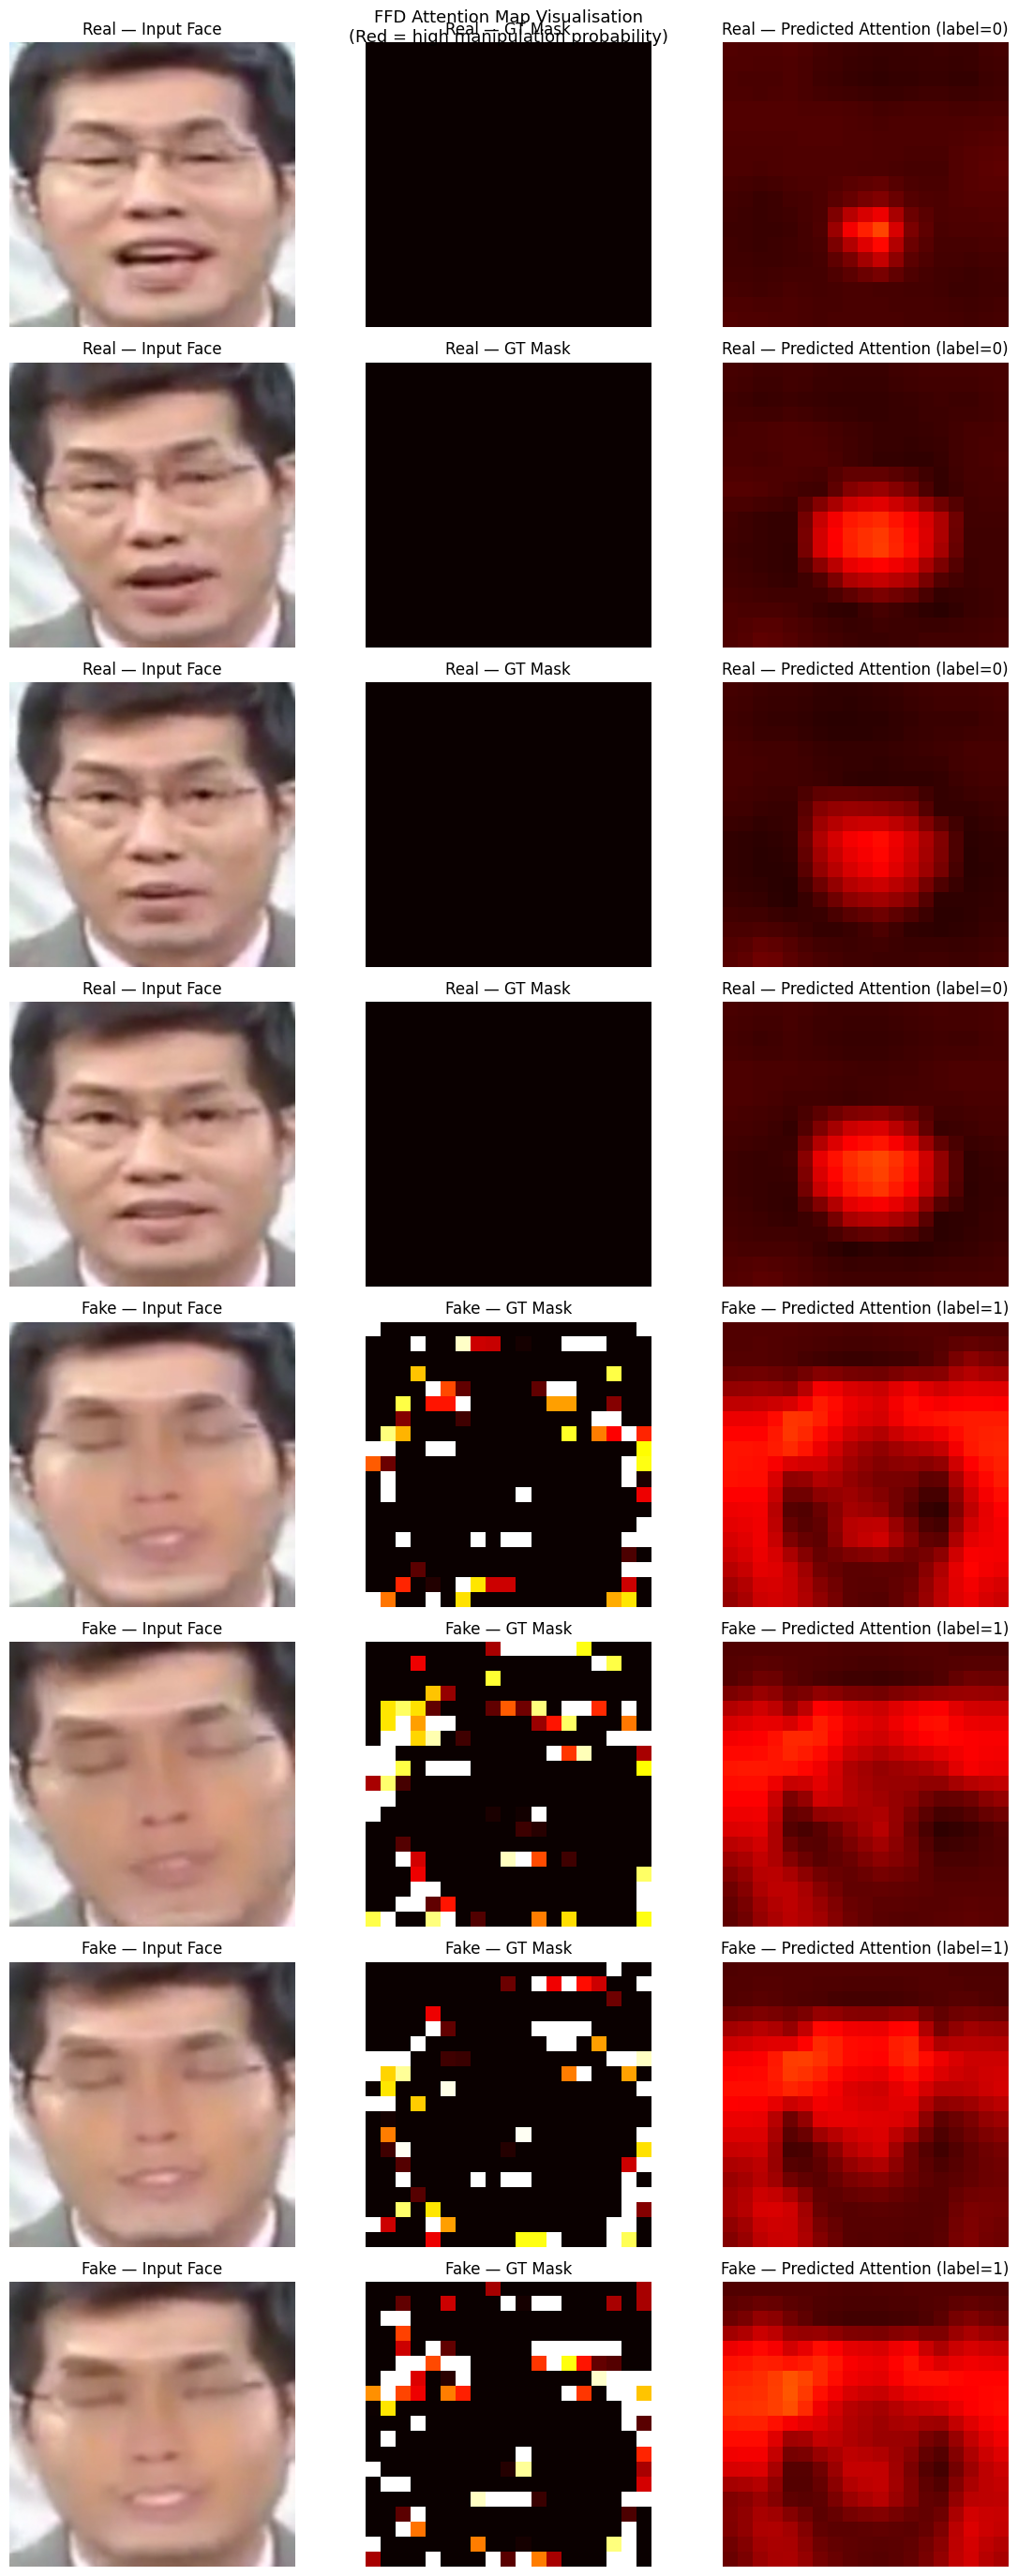

Attention map visualisation saved.


In [21]:
def visualise_attention(model, dataset, device, n_samples=4):
    """
    Plot side-by-side: original face | GT mask | predicted attention map
    for n_samples real and n_samples fake images.
    """
    model.eval()

    inv_normalize = transforms.Normalize(
        mean=[-1.0, -1.0, -1.0],
        std=[2.0, 2.0, 2.0]
    )

    real_indices = dataset.df[dataset.df["label"] == 0].index[:n_samples].tolist()
    fake_indices = dataset.df[dataset.df["label"] == 1].index[:n_samples].tolist()
    indices = real_indices + fake_indices
    titles_prefix = ["Real"] * n_samples + ["Fake"] * n_samples

    fig, axes = plt.subplots(
        len(indices), 3,
        figsize=(12, len(indices) * 3.5)
    )

    for row, (idx, prefix) in enumerate(zip(indices, titles_prefix)):
        img_tensor, gt_mask, label = dataset[idx]

        # ── predicted attention map ───────────────────────────
        with torch.no_grad():
            inp = img_tensor.unsqueeze(0).to(device)
            _, pred_attn, _ = model(inp)
            pred_attn = pred_attn.squeeze().cpu().numpy()  # (M, M)

        # ── un-normalise image for display ────────────────────
        img_display = inv_normalize(img_tensor)
        img_display = img_display.permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        gt_mask_np = gt_mask.squeeze().numpy()  # (M, M)

        # ── plot ──────────────────────────────────────────────
        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f"{prefix} — Input Face")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt_mask_np, cmap="hot", vmin=0, vmax=1)
        axes[row, 1].set_title(f"{prefix} — GT Mask")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_attn, cmap="hot", vmin=0, vmax=1)
        axes[row, 2].set_title(
            f"{prefix} — Predicted Attention"
            f" (label={int(label.item())})"
        )
        axes[row, 2].axis("off")

    plt.suptitle(
        "FFD Attention Map Visualisation\n"
        "(Red = high manipulation probability)",
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(MODEL_SAVE_PATH, "ffd_attention_maps.png"),
        dpi=150
    )
    plt.show()
    print("Attention map visualisation saved.")


visualise_attention(model, val_dataset, DEVICE, n_samples=4)

## Step 14 — Save Final Results Summary

In [22]:
results_df = pd.DataFrame({
    "epoch":      list(range(1, NUM_EPOCHS + 1)),
    "train_loss": history["train_loss"],
    "train_auc":  history["train_auc"],
    "train_cls":  history["train_cls"],
    "train_attn": history["train_attn"],
    "train_app":  history["train_app"],
    "val_loss":   history["val_loss"],
    "val_auc":    history["val_auc"],
    "val_acc":    history["val_acc"]
})

results_csv_path = os.path.join(MODEL_SAVE_PATH, "ffd_training_history.csv")
results_df.to_csv(results_csv_path, index=False)

print("=" * 50)
print("FFD MODEL — FINAL SUMMARY")
print("=" * 50)
print(f"  Best Val AUC    : {best_val_auc:.4f}")
print(f"  Test  AUC       : {test_auc:.4f}")
print(f"  Test  Accuracy  : {test_acc:.4f}")
print(f"  Model saved to  : {FFD_MODEL_PATH}")
print(f"  History saved to: {results_csv_path}")
print(results_df.to_string(index=False))

FFD MODEL — FINAL SUMMARY
  Best Val AUC    : 0.9748
  Test  AUC       : 0.9959
  Test  Accuracy  : 0.9548
  Model saved to  : /content/drive/MyDrive/Deepfake_Project/Models/ffd_best.pth
  History saved to: /content/drive/MyDrive/Deepfake_Project/Models/ffd_training_history.csv
 epoch  train_loss  train_auc  train_cls  train_attn  train_app  val_loss  val_auc  val_acc
     1    0.270032   0.988394   0.135296    0.121277   0.148195  0.283205 0.972803 0.887433
     2    0.144396   0.996543   0.067632    0.082029   0.071499  0.279787 0.974759 0.886242
     3    0.138998   0.996482   0.067686    0.073286   0.069339  0.282942 0.973370 0.885051
